In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. SAFELY LOAD THE 10GB FILE
# =====================================================================
subject_file = "/share/data1/mossf/data/brainlm/outputs/attention_matrices/Sub_0000_attention.npy"
raw_matrix = np.load(subject_file, mmap_mode='r')
print(f"Raw data shape on disk: {raw_matrix.shape}")

# =====================================================================
# 2. CORRECTED DOWNSAMPLING (TIME FIRST, REGION SECOND)
# =====================================================================
num_layers = raw_matrix.shape[0]
num_heads = raw_matrix.shape[1]
num_time_steps = 10 
num_regions = 424

print("Collapsing 10 time steps per region to save RAM...")

# Pre-allocate our clean 103 MB array
clean_data = np.zeros((num_layers, num_heads, num_regions, num_regions), dtype=np.float32)

for l in range(num_layers):
    # 1. Pull just one layer into RAM: shape (12, 4240, 4240)
    layer_raw = raw_matrix[l]
    
    # 2. THE FIX: Reshape with Time FIRST, Region SECOND
    # Shape becomes: (12 heads, 10 time_src, 424 reg_src, 10 time_tgt, 424 reg_tgt)
    reshaped = layer_raw.reshape(num_heads, num_time_steps, num_regions, num_time_steps, num_regions)
    
    # 3. Average across the Time dimensions (axis 1 for source, axis 3 for target)
    # New shape: (12, 424, 424)
    clean_data[l] = reshaped.mean(axis=(1, 3))

print(f"Downsampling complete. Clean shape: {clean_data.shape}")

Raw data shape on disk: (12, 12, 4240, 4240)
Collapsing 10 time steps per region to save RAM...
Downsampling complete. Clean shape: (12, 12, 424, 424)


In [15]:
avg_heads = layer_raw[-1]#.mean(axis=0)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
vmin = np.percentile(avg_heads, 5)
vmax = np.percentile(avg_heads, 95)
sns.heatmap(
            avg_heads, 
            cmap='viridis', 
            vmin=0, 
            vmax=vmax, 
            cbar=True, 
            ax=ax,
            xticklabels=False, 
            yticklabels=False
        )

In [ ]:
import os
import sys
import argparse
import logging
import h5py
import numpy as np
import torch


with h5py.File() as f_in:
        ts_dataset = f_in['parcel_ts']
        subject_ids = f_in['subject_ids'][:]
        n_subjects, _, num_regions_total = ts_dataset.shape

        for i in range(n_subjects):
            sub_id = subject_ids[i].decode('utf-8')
            out_file = os.path.join(args.output_dir, f"{sub_id}_attention.npy")
            
            # --- AUTO-RESUME CHECK ---
            if os.path.exists(out_file):
                logger.info(f"Skipping [{i+1}/{n_subjects}] | Subject ID: {sub_id} (Already processed)")
                continue

            try:
                raw_data = ts_dataset[i, :, :]
                fmri_windows = preprocess_subject_data(raw_data).to(device)

In [ ]:
# =====================================================================
# 3. VISUALIZATION
# =====================================================================
def plot_layer_heads(data, layer_idx):
    num_heads = data.shape[1]
    nrows, ncols = 3, 4
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))
    axes = axes.flatten()
    
    layer_data = data[layer_idx]
    
    for head_idx in range(num_heads):
        ax = axes[head_idx]
        head_matrix = layer_data[head_idx]
        
        vmin = np.percentile(head_matrix, 5)
        vmax = np.percentile(head_matrix, 95)
        
        sns.heatmap(
            head_matrix, 
            cmap='viridis', 
            vmin=vmin, 
            vmax=vmax, 
            cbar=False, 
            ax=ax,
            xticklabels=False, 
            yticklabels=False
        )
        
        ax.set_title(f"Head {head_idx}", fontsize=12)
        
        if head_idx >= (nrows - 1) * ncols:
            ax.set_xlabel("Target Region")
        if head_idx % ncols == 0:
            ax.set_ylabel("Source Region")

    plt.suptitle(f"Subject 0000: Multi-Head Attention Breakdown (Layer {layer_idx})", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

print("\nPlotting Layer 6 Multi-Head Attention...")
plot_layer_heads(clean_data, layer_idx=6)

Shape: (12, 12, 424, 424)


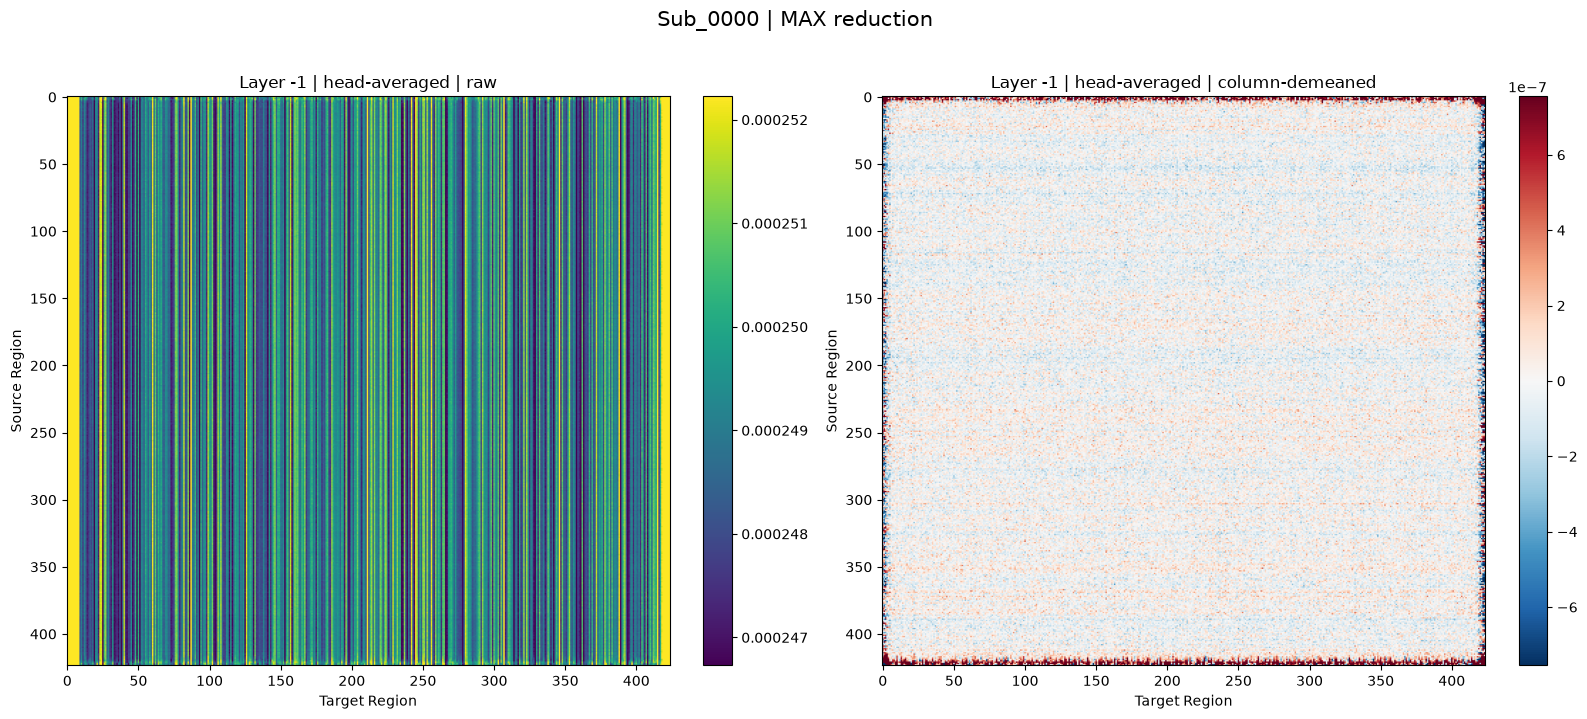

diagonal mean: 0.0002   off-diagonal mean: 0.0002   ratio: 1.00


In [12]:
import numpy as np
import matplotlib.pyplot as plt

subject_file = "/share/data1/mossf/data/brainlm/outputs/attention_matrices/Sub_0001_attention_max.npy"

data = np.load(subject_file)                 # (12 layers, 12 heads, 424, 424)
print(f"Shape: {data.shape}")
assert data.shape[-1] == 424, "Raw 4240 file — wrong loader."

# Average across heads, take the last layer
M = data[-1].mean(axis=0).astype(np.float32)   # (424, 424)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: raw head-averaged attention
raw = M
vmin, vmax = np.percentile(raw, 5), np.percentile(raw, 95)
im0 = axes[0].imshow(raw, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title("Layer -1 | head-averaged | raw")
axes[0].set_xlabel("Target Region"); axes[0].set_ylabel("Source Region")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

# Right: column-demeaned (sink removed)
dem = M - M.mean(axis=0, keepdims=True)
lim = np.percentile(np.abs(dem), 99)
im1 = axes[1].imshow(dem, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
axes[1].set_title("Layer -1 | head-averaged | column-demeaned")
axes[1].set_xlabel("Target Region"); axes[1].set_ylabel("Source Region")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.suptitle("Sub_0000 | MAX reduction", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Quick numeric gut-check: how much hotter is the diagonal than off-diagonal?
diag = np.diag(raw).mean()
off  = raw[~np.eye(424, dtype=bool)].mean()
print(f"diagonal mean: {diag:.4f}   off-diagonal mean: {off:.4f}   ratio: {diag/off:.2f}")